In [1]:
import os
import sys

sys.path.append('/data25/wuqin/projects/pytorch-grad-cam')
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['CUDA_VISIBLE_DEVICES'] = '5'
os.environ['HOME'] = '/data25/wuqin'
os.environ['CUDA_HOME'] = '/usr/local/cuda-11.8'

In [2]:
config_file = 'groundingdino/config/GroundingDINO_SwinB_cfg.py'
checkpoint_path = 'groundingdino_swinb_cogcoor.pth'

In [3]:
from demo.inference_on_a_image import load_image, load_model
model = load_model(config_file, checkpoint_path)

/data25/wuqin/miniforge3/envs/g_dino/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data25/wuqin/miniforge3/envs/g_dino/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/data25/wuqin/miniforge3/envs/g_dino/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


/data25/wuqin/projects/GroundingDINO/demo/inference_on_a_image.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_checkpoint_path, map_locati

_IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])


In [4]:
import torch
import torch.nn as nn
from typing import Optional
from groundingdino.util.utils import get_phrases_from_posmap

class GroundingDINO_CAM(nn.Module):
    """
    将 demo/inference_on_a_image.py 中的 get_grounding_output 封装为模块：
    - 在 forward 之前调用 set_prompt(caption, box_threshold, text_threshold)
    - forward(image: Tensor) 仅接收图像张量
    - 返回满足 logit > text_threshold 的所有 logit 的和（仅在 box 维度经 box_threshold 过滤后统计）
    """
    def __init__(self, model: nn.Module, cpu_only: bool = False, with_logits: bool = True) -> None:
        super().__init__()
        self.model = model
        self.caption: Optional[str] = None
        self.box_threshold: Optional[float] = None
        self.text_threshold: Optional[float] = None
        self.cpu_only = cpu_only
        self.with_logits = with_logits
        self.pred_boxes = self.pred_phrases = None

    def set_prompt(self, caption: str, box_threshold: float=0.3, text_threshold: float=0.25) -> None:
        caption = caption.lower().strip()
        if not caption.endswith("."):
            caption += "."
        self.caption = caption
        self.box_threshold = float(box_threshold)
        self.text_threshold = float(text_threshold)

    @torch.no_grad()
    def forward(self, image: torch.Tensor) -> torch.Tensor:
        assert self.caption is not None, "请先调用 set_prompt(caption, box_threshold, text_threshold)"
        assert self.box_threshold is not None and self.text_threshold is not None, "阈值未设置"

        device = "cuda" if (not self.cpu_only and torch.cuda.is_available()) else "cpu"
        model = self.model.to(device)
        image = image.to(device)

        outputs = model(image, captions=[self.caption])
        logits = outputs["pred_logits"].sigmoid()[0].cpu()  # (nq, 256)
        boxes = outputs["pred_boxes"][0].cpu()
        # 按 box 阈值先筛掉低质量 query（与原始函数一致：用每个 query 在 256 维 token 上的最大值做过滤）
        keep = logits.max(dim=1)[0] > self.box_threshold
        logits_kept = logits[keep]  # (num_filt, 256)
        boxes_kept = boxes[keep]  # (num_filt, 4)

        tokenlizer = model.tokenizer
        tokenized = tokenlizer(self.caption)
        # build pred
        pred_phrases = []
        for logit, box in zip(logits_kept, boxes_kept):
            pred_phrase = get_phrases_from_posmap(logit > self.text_threshold, tokenized, tokenlizer)
            if self.with_logits:
                pred_phrases.append(pred_phrase + f"({str(logit.max().item())[:4]})")
            else:
                pred_phrases.append(pred_phrase)
        self.pred_boxes = boxes_kept
        self.pred_phrases = pred_phrases

        # 统计超过 text_threshold 的 logit 之和
        mask = logits_kept > self.text_threshold
        logits_sum = (logits_kept[mask]).sum()
        return logits_sum

gdino_cam = GroundingDINO_CAM(model, cpu_only=False)

In [6]:
# 通过钩子获取多尺度特征空间尺度
spatial_shapes =[]
def get_spatial_shapes_hook(module, inputs):
    global spatial_shapes
    spatial_shapes.clear()
    if isinstance(inputs, tuple):
        srcs = inputs[0]
    elif isinstance(inputs, dict):
        srcs = inputs['srcs']
    for src in srcs:
        spatial_shapes.append(src.shape[-2:])
handle = gdino_cam.model.transformer.register_forward_pre_hook(get_spatial_shapes_hook)
# handle.remove()

In [7]:
# 重置特征尺度大小
class GDINOEncReshapeTransform:
    def __init__(self, idx=None):
        self.idx = idx

    def _recover_srcs(self, srcs_flatten):
        bs, l = srcs_flatten.shape[0], srcs_flatten.shape[1]
        srcs_recovered = []
        start_idx = 0
        for (h, w) in spatial_shapes:
            if start_idx >= l:
                break
            end_idx = start_idx + h * w
            # 取出当前层级的特征 [bs, h*w, c]
            src_level = srcs_flatten[:, start_idx:end_idx, :]
            # 恢复形状为 [bs, h, w, c] -> [bs, c, h, w]
            src_level = src_level.reshape(bs, h, w, -1).permute(0, 3, 1, 2)
            srcs_recovered.append(src_level)
            start_idx = end_idx
        return srcs_recovered

    def __call__(self, tensor):
        srcs = self._recover_srcs(tensor)
        if self.idx is None:
            target_size = srcs[0].shape[-2:]
            activations = []
            for feat in srcs:
                activations.append(
                    torch.nn.functional.interpolate(
                            torch.abs(feat),
                            target_size,
                            mode='bilinear'))
            activations = torch.cat(activations, axis=1)
            return activations
        return srcs[self.idx]

In [16]:
image_path = '/data25/wuqin/projects/pytorch-grad-cam/testset/test2.jpg'
text_prompt = 'plants'
image_pil, image = load_image(image_path)
print(image_pil.size)
print(image.shape)
gdino_cam.set_prompt(caption=text_prompt, box_threshold=0.3, text_threshold=0.25)

(4096, 3072)
torch.Size([3, 800, 1066])


CAM形状: (800, 1066)


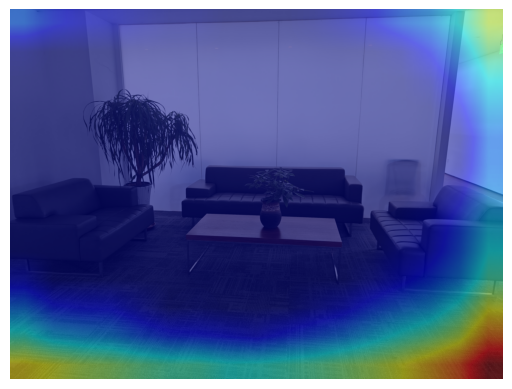

In [21]:
# 创建EigenCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam import EigenCAM
target_layers = [gdino_cam.model.transformer.enc_output]
# target_layers = [gdino_cam.model.backbone]
# target_layers = [gdino_cam.model.backbone[0].layers[-1].blocks[-1].norm2]

targets = [ClassifierOutputTarget(0)]

cam = EigenCAM(gdino_cam, target_layers, reshape_transform=GDINOEncReshapeTransform(3))
# cam = EigenCAM(gdino_cam, target_layers, reshape_transform=lambda x: x[0][2].tensors)
try:
    with torch.no_grad():
        grayscale_cam = cam(image[None], targets=targets)[0, :, :]
    print(f"CAM形状: {grayscale_cam.shape}")
except Exception as e:
    raise e
finally:
    for h in cam.activations_and_grads.handles:
        h.remove()
from pytorch_grad_cam.utils.image import show_cam_on_image
img = ((image-image.min()) / (image.max() - image.min())).permute(1, 2, 0).numpy()
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
import matplotlib.pyplot as plt
plt.imshow(cam_image)
plt.axis('off')
plt.show()

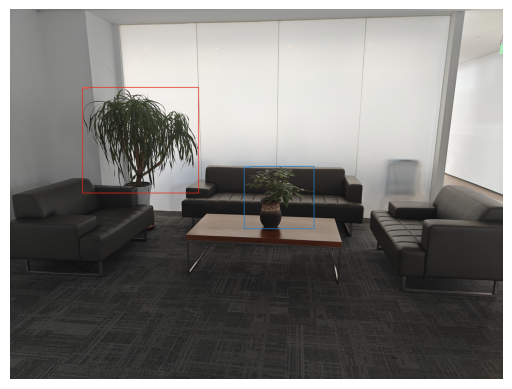

In [18]:
from demo.inference_on_a_image import plot_boxes_to_image
import matplotlib.pyplot as plt
# visualize pred
size = image_pil.size
pred_dict = {
    "boxes": gdino_cam.pred_boxes,
    "size": [size[1], size[0]],  # H,W
    "labels": gdino_cam.pred_phrases,
}
# import ipdb; ipdb.set_trace()
image_with_box = plot_boxes_to_image(image_pil, pred_dict)[0]
plt.imshow(image_with_box)
plt.axis('off')
plt.show()